# Code for the first figure of Section 5.13: Learning Initialization Distributions and Neonatal Locomotion in Ungulates


In [1]:
!nvidia-smi

Thu Apr 16 15:37:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")
class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            mask = (torch.rand_like(tensor) > sparsity).float()  # Keeps (1 - sparsity)% weights
            tensor *= mask
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, k=0.5, extra_capacity=0, double=True, **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        if double:
          multiplier=2
        else:
          multiplier=1
        self.scores = nn.Parameter(torch.randn(out_features,multiplier*in_features+extra_capacity))
        init(self.weight)
        self.weight.requires_grad_(False)
        self.scores.requires_grad_(True)
        if self.bias is not None:
          self.bias_scores = nn.Parameter(torch.randn(multiplier+extra_capacity,out_features))
          self.bias.requires_grad_(False)
          self.bias_scores.requires_grad_(True)
        self.mode= "mask"
        self.k=k
    def forward(self, x):
      if self.mode!= "static":
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[1,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)
      else:
        return F.linear(x,self.weight)

    def toggle_mode(self, mode):
        self.mode = mode
        if mode=='classic':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(False)
        if mode=='mask':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(True)
        if mode=='hybrid':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(True)
        if mode=='static':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(False)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, double=True, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias, double=double, extra_capacity=extra_capacity), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)
    def toggle_mode(self, mode):
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)
    def set_ks(self,ks):
        i=0
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k=ks[i]
                i+=1

Using cuda device


# weight distribution version

Generation 00: best test loss = 1.702703, mean = 101.152605, median = 18.587651, worst = 1228.511708, best test acc = 0.4844
Generation 01: best test loss = 1.272121, mean = 24.129063, median = 2.302585, worst = 948.446100, best test acc = 0.6356
Generation 02: best test loss = 1.536453, mean = 4.474149, median = 2.302585, worst = 190.826013, best test acc = 0.5044
Generation 03: best test loss = 1.440218, mean = 2.574320, median = 2.302585, worst = 45.805576, best test acc = 0.5400
Generation 04: best test loss = 1.565673, mean = 2.466406, median = 2.302585, worst = 27.841321, best test acc = 0.4689
Generation 05: best test loss = 1.299878, mean = 2.613196, median = 2.290966, worst = 43.461187, best test acc = 0.6378
Generation 06: best test loss = 1.046407, mean = 2.623826, median = 2.232224, worst = 45.474997, best test acc = 0.6911
Generation 07: best test loss = 1.133143, mean = 2.644454, median = 2.199750, worst = 28.855627, best test acc = 0.6311
Generation 08: best test loss = 

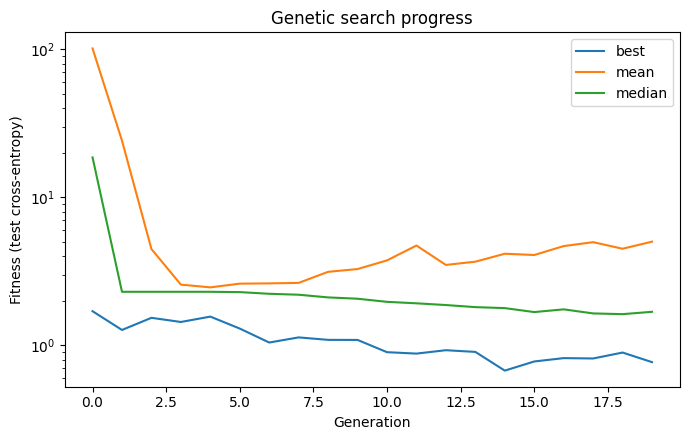

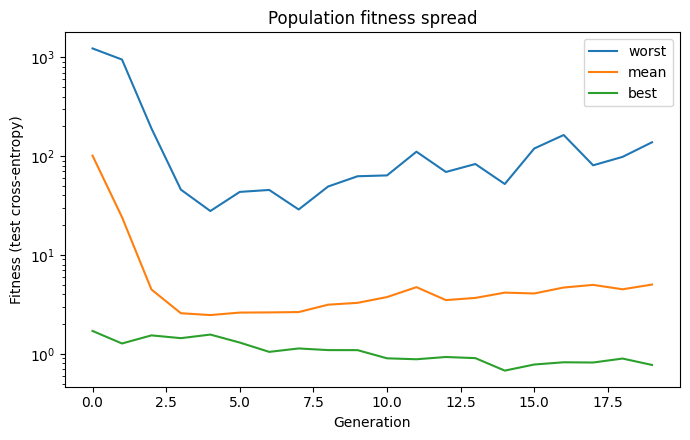

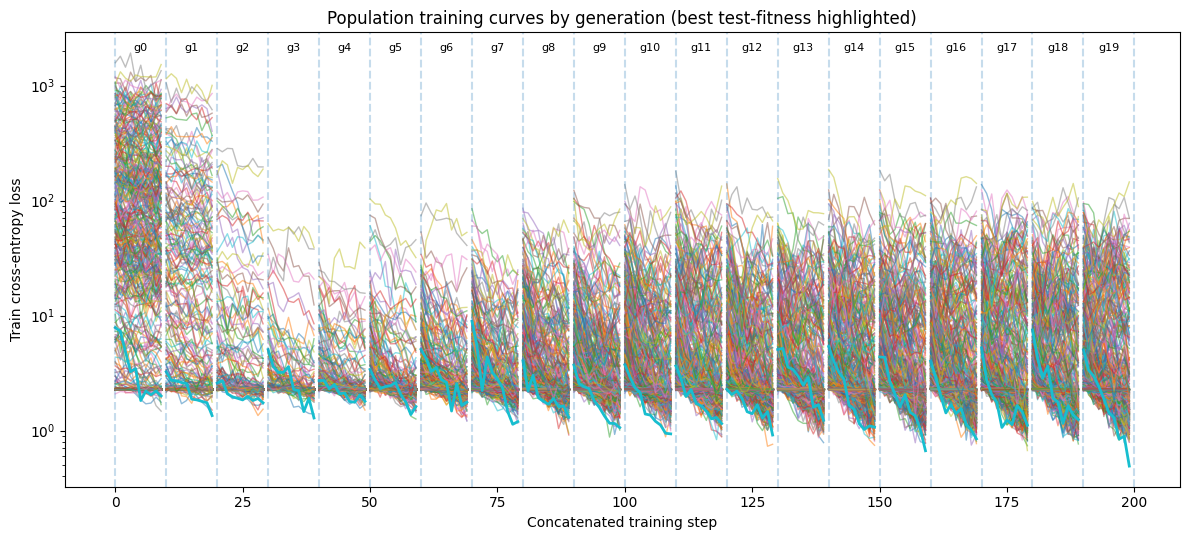

step 0: evolved train loss = 4.716884, baseline train loss = 2.315420, gap = -2.401464
step 1: evolved train loss = 4.492485, baseline train loss = 2.202243, gap = -2.290242
step 2: evolved train loss = 6.139772, baseline train loss = 2.277574, gap = -3.862199
step 3: evolved train loss = 3.309251, baseline train loss = 2.307688, gap = -1.001563
step 4: evolved train loss = 2.758106, baseline train loss = 2.193449, gap = -0.564657
step 5: evolved train loss = 2.534996, baseline train loss = 2.167369, gap = -0.367627
step 6: evolved train loss = 2.182386, baseline train loss = 2.075320, gap = -0.107066
step 7: evolved train loss = 1.480047, baseline train loss = 2.017364, gap = 0.537318
step 8: evolved train loss = 2.060491, baseline train loss = 1.926294, gap = -0.134197
step 9: evolved train loss = 1.432034, baseline train loss = 1.923906, gap = 0.491873


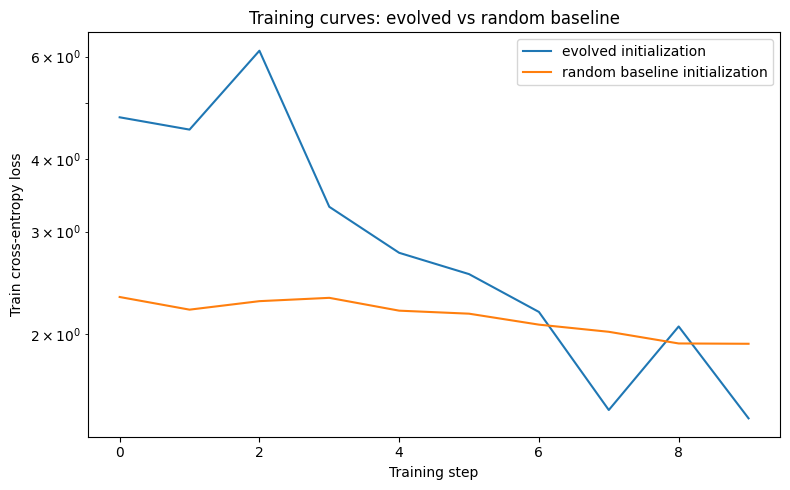

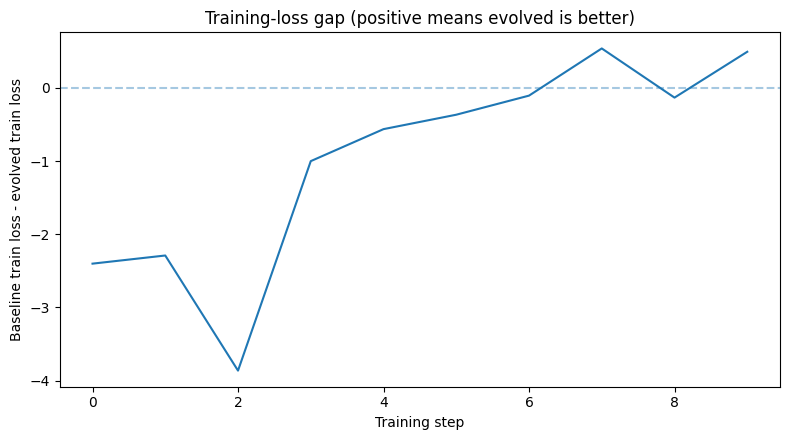

Evolved final train loss:   1.432034
Baseline final train loss:  1.923906
Evolved best train loss:    1.432034
Baseline best train loss:   1.923906

Evolved TEST loss:          1.855092
Baseline TEST loss:         1.833853
TEST loss gap:              -0.021239
Evolved TEST accuracy:      0.5911
Baseline TEST accuracy:     0.6867
TEST accuracy gap:          -0.0956


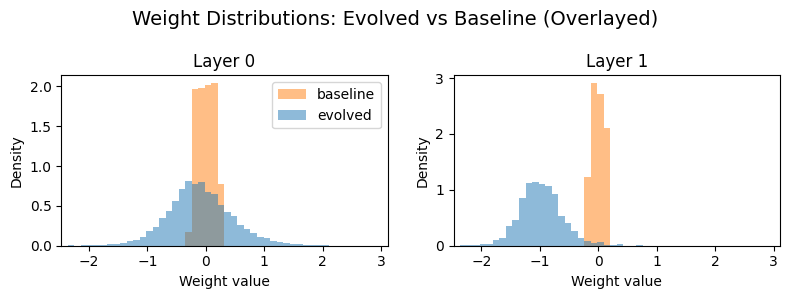

In [3]:
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ============================================================
# Fixed score initialization utilities
# ============================================================

def make_fixed_score_tensors(layer_sizes, bias=False, device='cpu',
                             score_init_type='normal',
                             score_std=1.0,
                             bias_score_std=1.0,
                             seed=0):
    """
    Create one fixed set of score tensors to be reused for every individual
    across all generations.
    """
    g = torch.Generator(device='cpu')
    g.manual_seed(seed)

    fixed_scores = {}

    for layer_idx, (in_features, out_features) in enumerate(layer_sizes):
        if score_init_type == 'normal':
            scores = torch.randn(out_features, 2 * in_features, generator=g) * score_std
            if bias:
                bias_scores = torch.randn(2, out_features, generator=g) * bias_score_std
            else:
                bias_scores = None
        elif score_init_type == 'zeros':
            scores = torch.zeros(out_features, 2 * in_features)
            bias_scores = torch.zeros(2, out_features) if bias else None
        else:
            raise ValueError(f"Unknown score_init_type: {score_init_type}")

        fixed_scores[layer_idx] = {
            "scores": scores.to(device),
            "bias_scores": None if bias_scores is None else bias_scores.to(device)
        }

    return fixed_scores


# ============================================================
# Genetic initialization + evaluation utilities
# ============================================================

def apply_genomic_init(model, individual, layer_sizes, fixed_scores, device='cpu'):
    """
    Apply initialization defined by `individual` to LinearSubnet layers.

    Weights are sampled from layerwise Gaussian fields parameterized by the genome.
    Score tensors are copied from `fixed_scores`, so every individual starts
    from exactly the same score initialization.
    """
    model.to(device)

    layer_idx = 0
    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            out_features, in_features = layer.weight.shape

            if out_features > 1:
                i_idx = torch.arange(out_features, device=device) / (out_features - 1)
            else:
                i_idx = torch.zeros(out_features, device=device)

            if in_features > 1:
                j_idx = torch.arange(in_features, device=device) / (in_features - 1)
            else:
                j_idx = torch.zeros(in_features, device=device)

            I, J = torch.meshgrid(i_idx, j_idx, indexing='ij')

            mu0 = individual[f"l{layer_idx}_mu0"]
            mu_i = individual[f"l{layer_idx}_mu_i"]
            mu_j = individual[f"l{layer_idx}_mu_j"]
            ls0 = individual[f"l{layer_idx}_ls0"]
            ls_i = individual[f"l{layer_idx}_ls_i"]
            ls_j = individual[f"l{layer_idx}_ls_j"]

            mu = mu0 + mu_i * I + mu_j * J
            log_sigma = ls0 + ls_i * I + ls_j * J
            sigma = torch.exp(log_sigma)

            eps = torch.randn_like(mu)
            W = mu + sigma * eps
            layer.weight.copy_(W)

            if hasattr(layer, "scores") and layer.scores is not None:
                layer.scores.copy_(fixed_scores[layer_idx]["scores"])

            if layer.bias is not None:
                layer.bias.zero_()

                if hasattr(layer, "bias_scores") and layer.bias_scores is not None:
                    fixed_bias_scores = fixed_scores[layer_idx]["bias_scores"]
                    if fixed_bias_scores is None:
                        layer.bias_scores.zero_()
                    else:
                        layer.bias_scores.copy_(fixed_bias_scores)

            layer_idx += 1

    model.toggle_mode("mask")
    return model


def make_random_individual(layer_sizes):
    """
    Random genome containing only weight-distribution parameters and LR.
    """
    n_layers = len(layer_sizes)
    ind = {}

    for l in range(n_layers):
        ind[f"l{l}_mu0"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_i"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_j"] = random.gauss(0.0, 1.0)

        ind[f"l{l}_ls0"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_i"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_j"] = random.uniform(-2.0, 0.0)

    ind["lr"] = 10 ** random.uniform(-4.0, -1.0)
    return ind


def mutate(individual, layer_sizes, mutation_scale=0.2):
    """
    Gaussian additive mutation on scalar genome parameters.
    """
    child = individual.copy()
    n_layers = len(layer_sizes)

    for l in range(n_layers):
        for key in [f"l{l}_mu0", f"l{l}_mu_i", f"l{l}_mu_j",
                    f"l{l}_ls0", f"l{l}_ls_i", f"l{l}_ls_j"]:
            child[key] = child[key] + random.gauss(0.0, mutation_scale)

    val = child["lr"]
    log_val = math.log(val + 1e-12)
    log_val += random.gauss(0.0, mutation_scale)
    child["lr"] = math.exp(log_val)

    return child


def crossover(parent1, parent2, layer_sizes):
    """
    Arithmetic crossover on all scalar genome parameters.
    """
    child = {}
    n_layers = len(layer_sizes)
    alpha = random.random()

    for l in range(n_layers):
        for key in [f"l{l}_mu0", f"l{l}_mu_i", f"l{l}_mu_j",
                    f"l{l}_ls0", f"l{l}_ls_i", f"l{l}_ls_j"]:
            child[key] = alpha * parent1[key] + (1 - alpha) * parent2[key]

    v1 = parent1["lr"]
    v2 = parent2["lr"]
    log_v1 = math.log(v1 + 1e-12)
    log_v2 = math.log(v2 + 1e-12)
    child["lr"] = math.exp(alpha * log_v1 + (1 - alpha) * log_v2)

    return child


def init_network_from_individual(individual, layer_sizes, fixed_scores, bias=False, device='cpu'):
    model = Network(layer_sizes, bias=bias)
    apply_genomic_init(model, individual, layer_sizes, fixed_scores=fixed_scores, device=device)
    return model


def init_random_baseline_network(layer_sizes, fixed_scores, bias=False, device='cpu'):
    """
    Ordinary random baseline model from Network, but with the same fixed score tensors.
    """
    model = Network(layer_sizes, bias=bias).to(device)

    layer_idx = 0
    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            if hasattr(layer, "scores") and layer.scores is not None:
                layer.scores.copy_(fixed_scores[layer_idx]["scores"])

            if layer.bias is not None and hasattr(layer, "bias_scores") and layer.bias_scores is not None:
                fixed_bias_scores = fixed_scores[layer_idx]["bias_scores"]
                if fixed_bias_scores is None:
                    layer.bias_scores.zero_()
                else:
                    layer.bias_scores.copy_(fixed_bias_scores)

            layer_idx += 1

    model.toggle_mode("mask")
    return model


def evaluate_model_on_dataloader(model, dataloader, device='cpu'):
    """
    Return average cross-entropy loss and accuracy over a dataloader.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = F.cross_entropy(logits, y, reduction='sum')
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == y).sum().item()
            total_examples += y.numel()

    if total_examples == 0:
        return float('inf'), 0.0

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


def evaluate_individual(individual,
                        train_dataloader,
                        test_dataloader,
                        layer_sizes,
                        fixed_scores,
                        bias=False,
                        device='cpu',
                        steps=50,
                        return_history=False):
    """
    Lower fitness = better.

    Procedure:
      1. initialize model from genome
      2. train for `steps` minibatches on train_dataloader
      3. evaluate average cross-entropy on test_dataloader
      4. use that TEST loss as the fitness
    """
    lr = individual["lr"]

    model = init_network_from_individual(
        individual,
        layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device
    )

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    train_step_losses = []

    model.train()
    for t, (X, y) in enumerate(train_dataloader):
        if t >= steps:
            break

        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        train_step_losses.append(loss.item())

    test_loss, test_acc = evaluate_model_on_dataloader(model, test_dataloader, device=device)

    if return_history:
        info = {
            "train_curve": train_step_losses,
            "best_trial_curve": train_step_losses,   # kept for compatibility with old plotting code
            "fitness_test_loss": test_loss,
            "fitness_test_acc": test_acc,
            "mean_best_loss": test_loss,             # kept for compatibility
        }
        return test_loss, info

    return test_loss


def evaluate_population(population,
                        train_dataloader,
                        test_dataloader,
                        layer_sizes,
                        fixed_scores,
                        bias=False,
                        device='cpu',
                        steps=50,
                        capture_curves=False):
    """
    Evaluate an entire population using TEST loss as fitness.
    """
    fitnesses = []
    infos = []

    for ind in population:
        if capture_curves:
            fit, info = evaluate_individual(
                ind,
                train_dataloader,
                test_dataloader,
                layer_sizes=layer_sizes,
                fixed_scores=fixed_scores,
                bias=bias,
                device=device,
                steps=steps,
                return_history=True
            )
            fitnesses.append(fit)
            infos.append(info)
        else:
            fit = evaluate_individual(
                ind,
                train_dataloader,
                test_dataloader,
                layer_sizes=layer_sizes,
                fixed_scores=fixed_scores,
                bias=bias,
                device=device,
                steps=steps,
                return_history=False
            )
            fitnesses.append(fit)

    if capture_curves:
        return fitnesses, infos
    return fitnesses


def run_genetic_search(
    train_dataloader,
    test_dataloader,
    layer_sizes=[[2, 2], [2, 2]],
    bias=False,
    device='cpu',
    pop_size=20,
    generations=30,
    elite_frac=0.25,
    mutation_prob=0.7,
    steps=50,
    fixed_scores=None,
):
    """
    Evolve initialization distributions using TEST loss as fitness.

    All individuals share the same fixed subnet score tensors.
    """
    if fixed_scores is None:
        raise ValueError("run_genetic_search requires a fixed_scores dictionary.")

    population = [make_random_individual(layer_sizes) for _ in range(pop_size)]

    fitnesses, infos = evaluate_population(
        population,
        train_dataloader,
        test_dataloader,
        layer_sizes=layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device,
        steps=steps,
        capture_curves=True
    )

    history = {
        "generation": [],
        "best_fitness": [],
        "mean_fitness": [],
        "median_fitness": [],
        "worst_fitness": [],
        "population_best_curves": [],
        "population_fitnesses": [],
        "population_test_accs": [],
        "best_indices": [],
    }

    for gen in range(generations):
        combined = list(zip(population, fitnesses, infos))
        combined.sort(key=lambda x: x[1])

        population = [x[0] for x in combined]
        fitnesses = [x[1] for x in combined]
        infos = [x[2] for x in combined]

        best_fit = fitnesses[0]
        mean_fit = float(np.mean(fitnesses))
        median_fit = float(np.median(fitnesses))
        worst_fit = fitnesses[-1]

        history["generation"].append(gen)
        history["best_fitness"].append(best_fit)
        history["mean_fitness"].append(mean_fit)
        history["median_fitness"].append(median_fit)
        history["worst_fitness"].append(worst_fit)
        history["population_best_curves"].append([info["best_trial_curve"] for info in infos])
        history["population_fitnesses"].append(list(fitnesses))
        history["population_test_accs"].append([info["fitness_test_acc"] for info in infos])
        history["best_indices"].append(0)

        print(
            f"Generation {gen:02d}: "
            f"best test loss = {best_fit:.6f}, "
            f"mean = {mean_fit:.6f}, "
            f"median = {median_fit:.6f}, "
            f"worst = {worst_fit:.6f}, "
            f"best test acc = {infos[0]['fitness_test_acc']:.4f}"
        )

        elite_count = max(1, int(elite_frac * pop_size))
        new_population = population[:elite_count]

        while len(new_population) < pop_size:
            parent1 = random.choice(population[:elite_count])
            parent2 = random.choice(population)

            child = crossover(parent1, parent2, layer_sizes)

            if random.random() < mutation_prob:
                child = mutate(child, layer_sizes)

            new_population.append(child)

        population = new_population

        fitnesses, infos = evaluate_population(
            population,
            train_dataloader,
            test_dataloader,
            layer_sizes=layer_sizes,
            fixed_scores=fixed_scores,
            bias=bias,
            device=device,
            steps=steps,
            capture_curves=True
        )

    combined = list(zip(population, fitnesses, infos))
    combined.sort(key=lambda x: x[1])
    best_ind, best_fit, best_info = combined[0]

    print("\nBest found initialization distribution:")
    for k, v in best_ind.items():
        print(f"  {k}: {v:.5f}")
    print(f"Best test loss: {best_fit:.6f}")
    print(f"Best test accuracy: {best_info['fitness_test_acc']:.4f}")

    return best_ind, best_fit, history


def train_best_model(best_individual,
                     train_dataloader,
                     test_dataloader,
                     layer_sizes,
                     fixed_scores,
                     bias=False,
                     steps=50,
                     device='cpu',
                     baseline_lr=None):
    """
    Train and compare:
      1. best evolved initialization
      2. fresh random baseline initialization

    Returns training curves and final test metrics for both.
    """
    evolved_model = init_network_from_individual(
        best_individual,
        layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device
    )

    baseline_model = init_random_baseline_network(
        layer_sizes,
        fixed_scores=fixed_scores,
        bias=bias,
        device=device
    )

    evolved_lr = best_individual["lr"]
    if baseline_lr is None:
        baseline_lr = evolved_lr

    evolved_optimizer = torch.optim.Adam(
        [p for p in evolved_model.parameters() if p.requires_grad],
        lr=evolved_lr
    )
    baseline_optimizer = torch.optim.Adam(
        [p for p in baseline_model.parameters() if p.requires_grad],
        lr=baseline_lr
    )

    evolved_losses = []
    baseline_losses = []

    evolved_model.train()
    baseline_model.train()

    for t, (X, y) in enumerate(train_dataloader):
        if t >= steps:
            break

        X, y = X.to(device), y.to(device)

        evolved_optimizer.zero_grad()
        evolved_logits = evolved_model(X)
        evolved_loss = F.cross_entropy(evolved_logits, y)
        evolved_loss.backward()
        evolved_optimizer.step()
        evolved_losses.append(evolved_loss.item())

        baseline_optimizer.zero_grad()
        baseline_logits = baseline_model(X)
        baseline_loss = F.cross_entropy(baseline_logits, y)
        baseline_loss.backward()
        baseline_optimizer.step()
        baseline_losses.append(baseline_loss.item())

        print(
            f"step {t}: "
            f"evolved train loss = {evolved_loss.item():.6f}, "
            f"baseline train loss = {baseline_loss.item():.6f}, "
            f"gap = {baseline_loss.item() - evolved_loss.item():.6f}"
        )

    evolved_test_loss, evolved_test_acc = evaluate_model_on_dataloader(
        evolved_model, test_dataloader, device=device
    )
    baseline_test_loss, baseline_test_acc = evaluate_model_on_dataloader(
        baseline_model, test_dataloader, device=device
    )

    results = {
        "evolved_model": evolved_model,
        "baseline_model": baseline_model,
        "evolved_losses": evolved_losses,
        "baseline_losses": baseline_losses,
        "evolved_final_loss": evolved_losses[-1] if len(evolved_losses) > 0 else None,
        "baseline_final_loss": baseline_losses[-1] if len(baseline_losses) > 0 else None,
        "final_gap": (
            baseline_losses[-1] - evolved_losses[-1]
            if len(evolved_losses) > 0 and len(baseline_losses) > 0 else None
        ),
        "evolved_best_loss": min(evolved_losses) if len(evolved_losses) > 0 else None,
        "baseline_best_loss": min(baseline_losses) if len(baseline_losses) > 0 else None,
        "best_gap": (
            min(baseline_losses) - min(evolved_losses)
            if len(evolved_losses) > 0 and len(baseline_losses) > 0 else None
        ),
        "evolved_test_loss": evolved_test_loss,
        "baseline_test_loss": baseline_test_loss,
        "evolved_test_acc": evolved_test_acc,
        "baseline_test_acc": baseline_test_acc,
        "test_loss_gap": baseline_test_loss - evolved_test_loss,
        "test_acc_gap": evolved_test_acc - baseline_test_acc,
    }

    return results


# ============================================================
# Plotting
# ============================================================

def plot_genetic_history(history):
    gens = np.array(history["generation"])
    best = np.array(history["best_fitness"])
    mean = np.array(history["mean_fitness"])
    median = np.array(history["median_fitness"])
    worst = np.array(history["worst_fitness"])

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, best, label="best")
    plt.plot(gens, mean, label="mean")
    plt.plot(gens, median, label="median")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (test cross-entropy)")
    plt.title("Genetic search progress")
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, worst, label="worst")
    plt.plot(gens, mean, label="mean")
    plt.plot(gens, best, label="best")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (test cross-entropy)")
    plt.title("Population fitness spread")
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_population_curves_concatenated(history,
                                        nonbest_alpha=0.06,
                                        best_alpha=0.95,
                                        draw_boundaries=True,
                                        label_generations=True,
                                        use_logy=False):
    """
    This shows the short TRAINING curves for individuals in each generation.
    Fitness itself is test loss, but these curves are still useful diagnostically.
    """
    generation_curves = history["population_best_curves"]
    generation_fitnesses = history["population_fitnesses"]
    generations = history["generation"]

    plt.figure(figsize=(12, 5.5))

    boundaries = [0]
    offset = 0

    all_y = []
    for curves in generation_curves:
        for curve in curves:
            all_y.extend(curve)
    ymax = max(all_y) if len(all_y) > 0 else 1.0

    for gen_idx, (curves, fits) in enumerate(zip(generation_curves, generation_fitnesses)):
        if len(curves) == 0:
            boundaries.append(offset)
            continue

        seg_len = len(curves[0]) if len(curves[0]) > 0 else 0
        best_idx = int(np.argmin(fits))
        draw_order = [i for i in range(len(curves)) if i != best_idx] + [best_idx]

        for i in draw_order:
            curve = curves[i]
            x = np.arange(offset, offset + len(curve))
            if i == best_idx:
                plt.plot(x, curve, alpha=best_alpha, linewidth=2.0)
            else:
                plt.plot(x, curve, alpha=nonbest_alpha, linewidth=1.0)

        offset += seg_len
        boundaries.append(offset)

    if draw_boundaries:
        for b in boundaries:
            plt.axvline(b, linestyle='--', alpha=0.25)

    if label_generations and len(boundaries) >= 2:
        for idx, gen in enumerate(generations):
            left = boundaries[idx]
            right = boundaries[idx + 1]
            mid = 0.5 * (left + right)
            plt.text(mid, ymax, f"g{gen}", ha='center', va='bottom', fontsize=8)

    plt.xlabel("Concatenated training step")
    plt.ylabel("Train cross-entropy loss")
    plt.title("Population training curves by generation (best test-fitness highlighted)")

    if use_logy:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


def plot_training_curve(results, use_logy=False):
    """
    Plot evolved vs random baseline training curves, plus their gap and final test metrics.
    """
    evolved_losses = results["evolved_losses"]
    baseline_losses = results["baseline_losses"]

    steps_arr = np.arange(len(evolved_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(steps_arr, evolved_losses, label="evolved initialization")
    plt.plot(steps_arr, baseline_losses, label="random baseline initialization")
    plt.xlabel("Training step")
    plt.ylabel("Train cross-entropy loss")
    plt.title("Training curves: evolved vs random baseline")
    if use_logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(evolved_losses) == len(baseline_losses) and len(evolved_losses) > 0:
        gap = np.array(baseline_losses) - np.array(evolved_losses)

        plt.figure(figsize=(8, 4.5))
        plt.plot(steps_arr, gap)
        plt.axhline(0.0, linestyle='--', alpha=0.4)
        plt.xlabel("Training step")
        plt.ylabel("Baseline train loss - evolved train loss")
        plt.title("Training-loss gap (positive means evolved is better)")
        plt.tight_layout()
        plt.show()

    print(f"Evolved final train loss:   {results['evolved_final_loss']:.6f}")
    print(f"Baseline final train loss:  {results['baseline_final_loss']:.6f}")
    print(f"Evolved best train loss:    {results['evolved_best_loss']:.6f}")
    print(f"Baseline best train loss:   {results['baseline_best_loss']:.6f}")
    print()
    print(f"Evolved TEST loss:          {results['evolved_test_loss']:.6f}")
    print(f"Baseline TEST loss:         {results['baseline_test_loss']:.6f}")
    print(f"TEST loss gap:              {results['test_loss_gap']:.6f}")
    print(f"Evolved TEST accuracy:      {results['evolved_test_acc']:.4f}")
    print(f"Baseline TEST accuracy:     {results['baseline_test_acc']:.4f}")
    print(f"TEST accuracy gap:          {results['test_acc_gap']:.4f}")


def plot_weight_histograms_overlay(
    evolved_model,
    baseline_model,
    bins=40,
    alpha=0.5,
    same_xlim=True,
    same_ylim=False,
):
    """
    Overlay histograms of evolved vs baseline weights for all layers.
    """
    evolved_layers = [l for l in evolved_model.layers if isinstance(l, LinearSubnet)]
    baseline_layers = [l for l in baseline_model.layers if isinstance(l, LinearSubnet)]

    assert len(evolved_layers) == len(baseline_layers)

    n_layers = len(evolved_layers)
    ncols = int(np.ceil(np.sqrt(n_layers)))
    nrows = int(np.ceil(n_layers / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).reshape(-1)

    global_min = float('inf')
    global_max = float('-inf')

    if same_xlim:
        for l1, l2 in zip(evolved_layers, baseline_layers):
            w1 = l1.weight.detach().cpu().numpy().ravel()
            w2 = l2.weight.detach().cpu().numpy().ravel()
            global_min = min(global_min, w1.min(), w2.min())
            global_max = max(global_max, w1.max(), w2.max())

    global_ymax = 0
    hist_data = []

    for l1, l2 in zip(evolved_layers, baseline_layers):
        w1 = l1.weight.detach().cpu().numpy().ravel()
        w2 = l2.weight.detach().cpu().numpy().ravel()

        if same_xlim:
            bins_edges = np.linspace(global_min, global_max, bins + 1)
        else:
            combined = np.concatenate([w1, w2])
            bins_edges = np.histogram_bin_edges(combined, bins=bins)

        h1, _ = np.histogram(w1, bins=bins_edges, density=True)
        h2, _ = np.histogram(w2, bins=bins_edges, density=True)
        global_ymax = max(global_ymax, h1.max(), h2.max())

        hist_data.append((w1, w2, bins_edges))

    for idx, ax in enumerate(axes):
        if idx >= n_layers:
            ax.axis("off")
            continue

        w1, w2, bins_edges = hist_data[idx]

        ax.hist(w2, bins=bins_edges, alpha=alpha, density=True, label="baseline", color='tab:orange')
        ax.hist(w1, bins=bins_edges, alpha=alpha, density=True, label="evolved", color='tab:blue')

        ax.set_title(f"Layer {idx}")
        ax.set_xlabel("Weight value")
        ax.set_ylabel("Density")

        if same_xlim:
            ax.set_xlim(global_min, global_max)
        if same_ylim:
            ax.set_ylim(0, global_ymax)

        if idx == 0:
            ax.legend()

    plt.suptitle("Weight Distributions: Evolved vs Baseline (Overlayed)", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run experiment
# ============================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_sizes = [[64, 256], [256, 10]]

from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

fixed_scores = make_fixed_score_tensors(
    layer_sizes=layer_sizes,
    bias=True,
    device=device,
    score_init_type='normal',   # or 'zeros'
    score_std=1.0,
    bias_score_std=1.0,
    seed=0
)

best_individual, best_fitness, genetic_history = run_genetic_search(
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    layer_sizes=layer_sizes,
    bias=True,
    device=device,
    pop_size=500,
    generations=20,
    steps=10,
    fixed_scores=fixed_scores
)

plot_genetic_history(genetic_history)

plot_population_curves_concatenated(
    genetic_history,
    nonbest_alpha=0.5,
    best_alpha=1.0,
    use_logy=True
)

comparison_results = train_best_model(
    best_individual=best_individual,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    layer_sizes=layer_sizes,
    fixed_scores=fixed_scores,
    bias=True,
    steps=10,
    device=device
)

plot_training_curve(comparison_results, use_logy=True)

plot_weight_histograms_overlay(
    evolved_model=comparison_results["evolved_model"],
    baseline_model=comparison_results["baseline_model"],
    bins=50,
    alpha=0.5,
    same_xlim=True,
    same_ylim=False
)

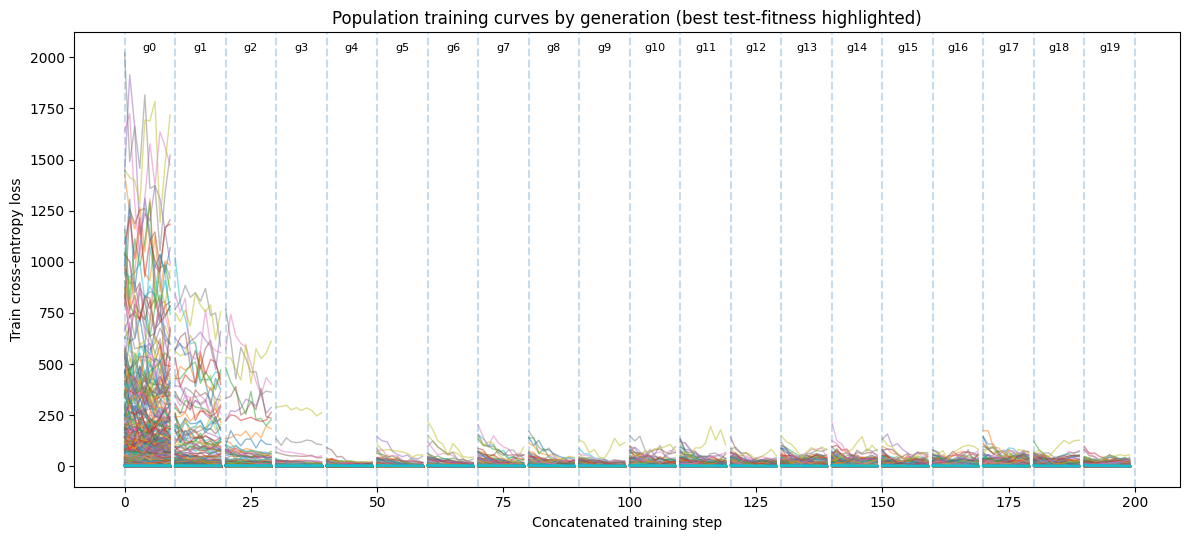

In [4]:
plot_population_curves_concatenated(
    genetic_history,
    nonbest_alpha=0.5,
    best_alpha=1.0,
    use_logy=False
)

Generation 00: best test loss = 1.566791, mean = 203.175973, median = 15.870286, worst = 3083.689080, best test acc = 0.4756
Generation 01: best test loss = 1.535998, mean = 43.537240, median = 2.302585, worst = 2514.838441, best test acc = 0.5200
Generation 02: best test loss = 1.426478, mean = 8.005709, median = 2.302585, worst = 638.011417, best test acc = 0.4822
Generation 03: best test loss = 1.346712, mean = 3.549594, median = 2.302585, worst = 226.801324, best test acc = 0.5756
Generation 04: best test loss = 1.449223, mean = 3.004284, median = 2.302585, worst = 130.849479, best test acc = 0.5400
Generation 05: best test loss = 0.841669, mean = 3.144831, median = 2.301369, worst = 76.982352, best test acc = 0.7156
Generation 06: best test loss = 0.866702, mean = 3.239564, median = 2.271136, worst = 90.708932, best test acc = 0.7489
Generation 07: best test loss = 0.846301, mean = 3.516789, median = 2.213045, worst = 89.870801, best test acc = 0.7244
Generation 08: best test loss

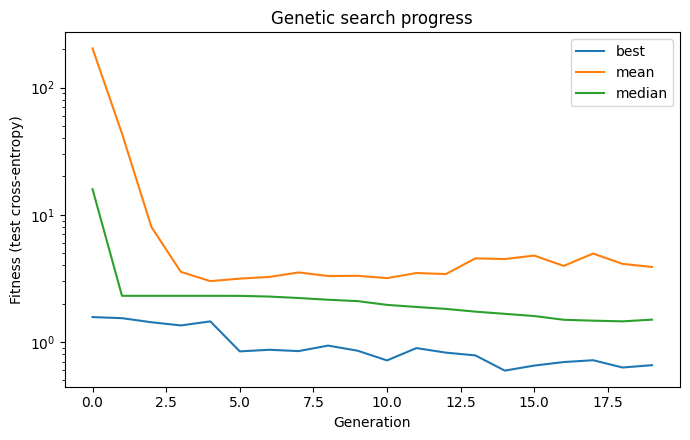

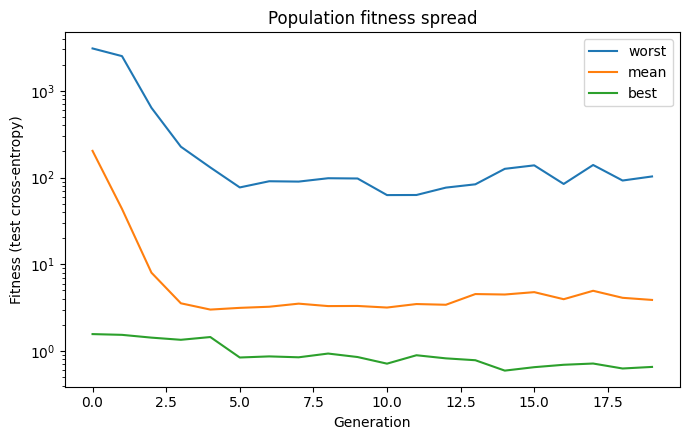

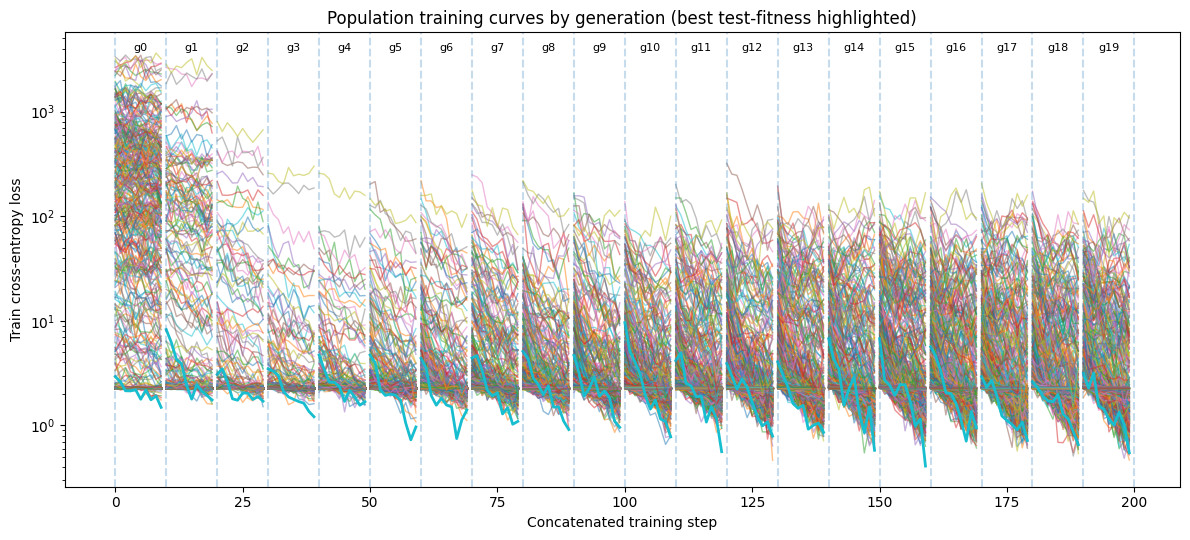

step 0: evolved train loss = 3.270092, baseline train loss = 2.385247, gap = -0.884845
step 1: evolved train loss = 2.342929, baseline train loss = 2.292635, gap = -0.050294
step 2: evolved train loss = 2.218191, baseline train loss = 2.200024, gap = -0.018167
step 3: evolved train loss = 1.950494, baseline train loss = 2.177447, gap = 0.226953
step 4: evolved train loss = 1.794962, baseline train loss = 2.159738, gap = 0.364776
step 5: evolved train loss = 1.621512, baseline train loss = 2.122432, gap = 0.500920
step 6: evolved train loss = 1.429717, baseline train loss = 2.100038, gap = 0.670321
step 7: evolved train loss = 1.048758, baseline train loss = 1.977637, gap = 0.928879
step 8: evolved train loss = 1.262211, baseline train loss = 2.034674, gap = 0.772462
step 9: evolved train loss = 1.117403, baseline train loss = 1.968934, gap = 0.851531


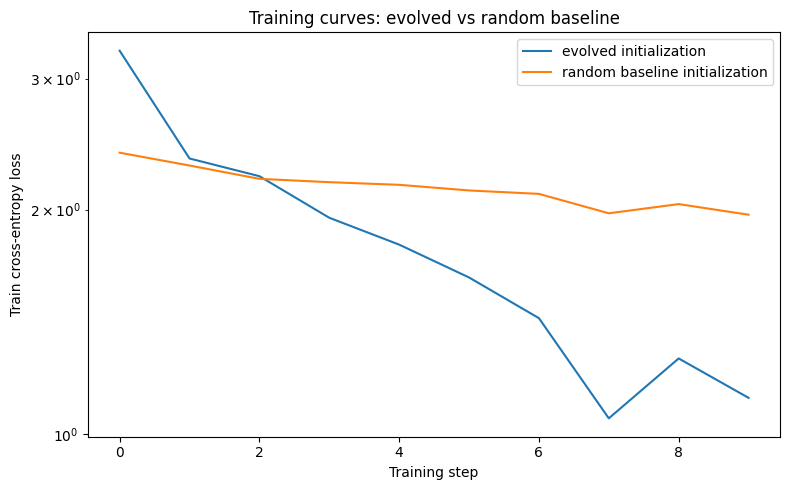

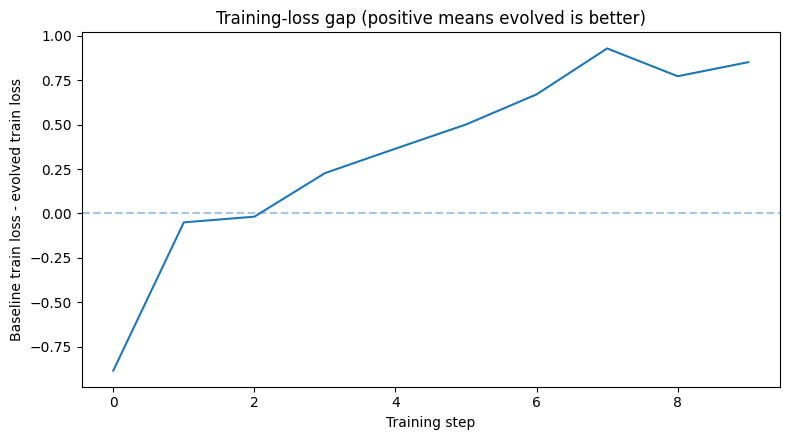

Evolved final train loss:   1.117403
Baseline final train loss:  1.968934
Evolved best train loss:    1.048758
Baseline best train loss:   1.968934

Evolved TEST loss:          0.887217
Baseline TEST loss:         1.873854
TEST loss gap:              0.986638
Evolved TEST accuracy:      0.7778
Baseline TEST accuracy:     0.5933
TEST accuracy gap:          0.1844


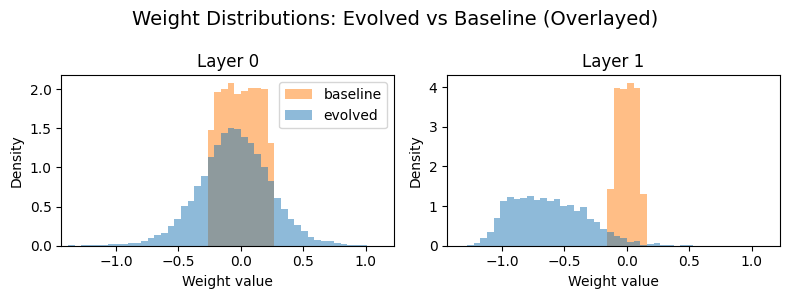

In [4]:
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ============================================================
# Random score initialization utilities
# ============================================================

def randomize_model_scores(model,
                           bias=False,
                           device='cpu',
                           score_init_type='normal',
                           score_std=1.0,
                           bias_score_std=1.0):
    """
    Reinitialize subnet score tensors randomly for this specific model instance.

    Unlike the old fixed-score setup, this is called every time a model is
    initialized, so each individual gets fresh random score tensors.
    """
    model.to(device)

    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            if hasattr(layer, "scores") and layer.scores is not None:
                if score_init_type == 'normal':
                    layer.scores.copy_(torch.randn_like(layer.scores) * score_std)
                elif score_init_type == 'zeros':
                    layer.scores.zero_()
                else:
                    raise ValueError(f"Unknown score_init_type: {score_init_type}")

            if layer.bias is not None and hasattr(layer, "bias_scores") and layer.bias_scores is not None:
                if score_init_type == 'normal':
                    layer.bias_scores.copy_(torch.randn_like(layer.bias_scores) * bias_score_std)
                elif score_init_type == 'zeros':
                    layer.bias_scores.zero_()
                else:
                    raise ValueError(f"Unknown score_init_type: {score_init_type}")

    return model


# ============================================================
# Genetic initialization + evaluation utilities
# ============================================================

def apply_genomic_init(model,
                       individual,
                       layer_sizes,
                       device='cpu',
                       score_init_type='normal',
                       score_std=1.0,
                       bias_score_std=1.0):
    """
    Apply initialization defined by `individual` to LinearSubnet layers.

    Weights are sampled from layerwise Gaussian fields parameterized by the genome.
    Score tensors are freshly randomized for each model instance.
    """
    model.to(device)

    layer_idx = 0
    with torch.no_grad():
        for layer in model.layers:
            if not isinstance(layer, LinearSubnet):
                continue

            out_features, in_features = layer.weight.shape

            if out_features > 1:
                i_idx = torch.arange(out_features, device=device) / (out_features - 1)
            else:
                i_idx = torch.zeros(out_features, device=device)

            if in_features > 1:
                j_idx = torch.arange(in_features, device=device) / (in_features - 1)
            else:
                j_idx = torch.zeros(in_features, device=device)

            I, J = torch.meshgrid(i_idx, j_idx, indexing='ij')

            mu0 = individual[f"l{layer_idx}_mu0"]
            mu_i = individual[f"l{layer_idx}_mu_i"]
            mu_j = individual[f"l{layer_idx}_mu_j"]
            ls0 = individual[f"l{layer_idx}_ls0"]
            ls_i = individual[f"l{layer_idx}_ls_i"]
            ls_j = individual[f"l{layer_idx}_ls_j"]

            mu = mu0 + mu_i * I + mu_j * J
            log_sigma = ls0 + ls_i * I + ls_j * J
            sigma = torch.exp(log_sigma)

            eps = torch.randn_like(mu)
            W = mu + sigma * eps
            layer.weight.copy_(W)

            if layer.bias is not None:
                layer.bias.zero_()

            layer_idx += 1

    # Fresh random scores for this individual/model instance
    randomize_model_scores(
        model,
        bias=(model.layers[0].bias is not None if len(model.layers) > 0 and isinstance(model.layers[0], LinearSubnet) else bias),
        device=device,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )

    model.toggle_mode("mask")
    return model


def make_random_individual(layer_sizes):
    """
    Random genome containing only weight-distribution parameters and LR.
    """
    n_layers = len(layer_sizes)
    ind = {}

    for l in range(n_layers):
        ind[f"l{l}_mu0"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_i"] = random.gauss(0.0, 1.0)
        ind[f"l{l}_mu_j"] = random.gauss(0.0, 1.0)

        ind[f"l{l}_ls0"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_i"] = random.uniform(-2.0, 0.0)
        ind[f"l{l}_ls_j"] = random.uniform(-2.0, 0.0)

    ind["lr"] = 10 ** random.uniform(-4.0, -1.0)
    return ind


def mutate(individual, layer_sizes, mutation_scale=0.2):
    """
    Gaussian additive mutation on scalar genome parameters.
    """
    child = individual.copy()
    n_layers = len(layer_sizes)

    for l in range(n_layers):
        for key in [f"l{l}_mu0", f"l{l}_mu_i", f"l{l}_mu_j",
                    f"l{l}_ls0", f"l{l}_ls_i", f"l{l}_ls_j"]:
            child[key] = child[key] + random.gauss(0.0, mutation_scale)

    val = child["lr"]
    log_val = math.log(val + 1e-12)
    log_val += random.gauss(0.0, mutation_scale)
    child["lr"] = math.exp(log_val)

    return child


def crossover(parent1, parent2, layer_sizes):
    """
    Arithmetic crossover on all scalar genome parameters.
    """
    child = {}
    n_layers = len(layer_sizes)
    alpha = random.random()

    for l in range(n_layers):
        for key in [f"l{l}_mu0", f"l{l}_mu_i", f"l{l}_mu_j",
                    f"l{l}_ls0", f"l{l}_ls_i", f"l{l}_ls_j"]:
            child[key] = alpha * parent1[key] + (1 - alpha) * parent2[key]

    v1 = parent1["lr"]
    v2 = parent2["lr"]
    log_v1 = math.log(v1 + 1e-12)
    log_v2 = math.log(v2 + 1e-12)
    child["lr"] = math.exp(alpha * log_v1 + (1 - alpha) * log_v2)

    return child


def init_network_from_individual(individual,
                                 layer_sizes,
                                 bias=False,
                                 device='cpu',
                                 score_init_type='normal',
                                 score_std=1.0,
                                 bias_score_std=1.0):
    model = Network(layer_sizes, bias=bias)
    apply_genomic_init(
        model,
        individual,
        layer_sizes,
        device=device,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )
    return model


def init_random_baseline_network(layer_sizes,
                                 bias=False,
                                 device='cpu',
                                 score_init_type='normal',
                                 score_std=1.0,
                                 bias_score_std=1.0):
    """
    Ordinary random baseline model from Network, with fresh random score tensors.
    """
    model = Network(layer_sizes, bias=bias).to(device)

    randomize_model_scores(
        model,
        bias=bias,
        device=device,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )

    model.toggle_mode("mask")
    return model


def evaluate_model_on_dataloader(model, dataloader, device='cpu'):
    """
    Return average cross-entropy loss and accuracy over a dataloader.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = F.cross_entropy(logits, y, reduction='sum')
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == y).sum().item()
            total_examples += y.numel()

    if total_examples == 0:
        return float('inf'), 0.0

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


def evaluate_individual(individual,
                        train_dataloader,
                        test_dataloader,
                        layer_sizes,
                        bias=False,
                        device='cpu',
                        steps=50,
                        return_history=False,
                        score_init_type='normal',
                        score_std=1.0,
                        bias_score_std=1.0):
    """
    Lower fitness = better.

    Procedure:
      1. initialize model from genome
      2. train for `steps` minibatches on train_dataloader
      3. evaluate average cross-entropy on test_dataloader
      4. use that TEST loss as the fitness

    Each call gets a freshly randomized score initialization.
    """
    lr = individual["lr"]

    model = init_network_from_individual(
        individual,
        layer_sizes,
        bias=bias,
        device=device,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    train_step_losses = []

    model.train()
    for t, (X, y) in enumerate(train_dataloader):
        if t >= steps:
            break

        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        train_step_losses.append(loss.item())

    test_loss, test_acc = evaluate_model_on_dataloader(model, test_dataloader, device=device)

    if return_history:
        info = {
            "train_curve": train_step_losses,
            "best_trial_curve": train_step_losses,   # kept for compatibility with old plotting code
            "fitness_test_loss": test_loss,
            "fitness_test_acc": test_acc,
            "mean_best_loss": test_loss,             # kept for compatibility
        }
        return test_loss, info

    return test_loss


def evaluate_population(population,
                        train_dataloader,
                        test_dataloader,
                        layer_sizes,
                        bias=False,
                        device='cpu',
                        steps=50,
                        capture_curves=False,
                        score_init_type='normal',
                        score_std=1.0,
                        bias_score_std=1.0):
    """
    Evaluate an entire population using TEST loss as fitness.
    """
    fitnesses = []
    infos = []

    for ind in population:
        if capture_curves:
            fit, info = evaluate_individual(
                ind,
                train_dataloader,
                test_dataloader,
                layer_sizes=layer_sizes,
                bias=bias,
                device=device,
                steps=steps,
                return_history=True,
                score_init_type=score_init_type,
                score_std=score_std,
                bias_score_std=bias_score_std
            )
            fitnesses.append(fit)
            infos.append(info)
        else:
            fit = evaluate_individual(
                ind,
                train_dataloader,
                test_dataloader,
                layer_sizes=layer_sizes,
                bias=bias,
                device=device,
                steps=steps,
                return_history=False,
                score_init_type=score_init_type,
                score_std=score_std,
                bias_score_std=bias_score_std
            )
            fitnesses.append(fit)

    if capture_curves:
        return fitnesses, infos
    return fitnesses


def run_genetic_search(
    train_dataloader,
    test_dataloader,
    layer_sizes=[[2, 2], [2, 2]],
    bias=False,
    device='cpu',
    pop_size=20,
    generations=30,
    elite_frac=0.25,
    mutation_prob=0.7,
    steps=50,
    score_init_type='normal',
    score_std=1.0,
    bias_score_std=1.0,
):
    """
    Evolve initialization distributions using TEST loss as fitness.

    Unlike the old version, individuals do NOT share a fixed score initialization.
    Each evaluation gets a fresh random set of subnet score tensors.
    """
    population = [make_random_individual(layer_sizes) for _ in range(pop_size)]

    fitnesses, infos = evaluate_population(
        population,
        train_dataloader,
        test_dataloader,
        layer_sizes=layer_sizes,
        bias=bias,
        device=device,
        steps=steps,
        capture_curves=True,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )

    history = {
        "generation": [],
        "best_fitness": [],
        "mean_fitness": [],
        "median_fitness": [],
        "worst_fitness": [],
        "population_best_curves": [],
        "population_fitnesses": [],
        "population_test_accs": [],
        "best_indices": [],
    }

    for gen in range(generations):
        combined = list(zip(population, fitnesses, infos))
        combined.sort(key=lambda x: x[1])

        population = [x[0] for x in combined]
        fitnesses = [x[1] for x in combined]
        infos = [x[2] for x in combined]

        best_fit = fitnesses[0]
        mean_fit = float(np.mean(fitnesses))
        median_fit = float(np.median(fitnesses))
        worst_fit = fitnesses[-1]

        history["generation"].append(gen)
        history["best_fitness"].append(best_fit)
        history["mean_fitness"].append(mean_fit)
        history["median_fitness"].append(median_fit)
        history["worst_fitness"].append(worst_fit)
        history["population_best_curves"].append([info["best_trial_curve"] for info in infos])
        history["population_fitnesses"].append(list(fitnesses))
        history["population_test_accs"].append([info["fitness_test_acc"] for info in infos])
        history["best_indices"].append(0)

        print(
            f"Generation {gen:02d}: "
            f"best test loss = {best_fit:.6f}, "
            f"mean = {mean_fit:.6f}, "
            f"median = {median_fit:.6f}, "
            f"worst = {worst_fit:.6f}, "
            f"best test acc = {infos[0]['fitness_test_acc']:.4f}"
        )

        elite_count = max(1, int(elite_frac * pop_size))
        new_population = population[:elite_count]

        while len(new_population) < pop_size:
            parent1 = random.choice(population[:elite_count])
            parent2 = random.choice(population)

            child = crossover(parent1, parent2, layer_sizes)

            if random.random() < mutation_prob:
                child = mutate(child, layer_sizes)

            new_population.append(child)

        population = new_population

        fitnesses, infos = evaluate_population(
            population,
            train_dataloader,
            test_dataloader,
            layer_sizes=layer_sizes,
            bias=bias,
            device=device,
            steps=steps,
            capture_curves=True,
            score_init_type=score_init_type,
            score_std=score_std,
            bias_score_std=bias_score_std
        )

    combined = list(zip(population, fitnesses, infos))
    combined.sort(key=lambda x: x[1])
    best_ind, best_fit, best_info = combined[0]

    print("\nBest found initialization distribution:")
    for k, v in best_ind.items():
        print(f"  {k}: {v:.5f}")
    print(f"Best test loss: {best_fit:.6f}")
    print(f"Best test accuracy: {best_info['fitness_test_acc']:.4f}")

    return best_ind, best_fit, history


def train_best_model(best_individual,
                     train_dataloader,
                     test_dataloader,
                     layer_sizes,
                     bias=False,
                     steps=50,
                     device='cpu',
                     baseline_lr=None,
                     score_init_type='normal',
                     score_std=1.0,
                     bias_score_std=1.0):
    """
    Train and compare:
      1. best evolved initialization
      2. fresh random baseline initialization

    Returns training curves and final test metrics for both.

    Each model gets its own fresh random score tensors.
    """
    evolved_model = init_network_from_individual(
        best_individual,
        layer_sizes,
        bias=bias,
        device=device,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )

    baseline_model = init_random_baseline_network(
        layer_sizes,
        bias=bias,
        device=device,
        score_init_type=score_init_type,
        score_std=score_std,
        bias_score_std=bias_score_std
    )

    evolved_lr = best_individual["lr"]
    if baseline_lr is None:
        baseline_lr = evolved_lr

    evolved_optimizer = torch.optim.Adam(
        [p for p in evolved_model.parameters() if p.requires_grad],
        lr=evolved_lr
    )
    baseline_optimizer = torch.optim.Adam(
        [p for p in baseline_model.parameters() if p.requires_grad],
        lr=baseline_lr
    )

    evolved_losses = []
    baseline_losses = []

    evolved_model.train()
    baseline_model.train()

    for t, (X, y) in enumerate(train_dataloader):
        if t >= steps:
            break

        X, y = X.to(device), y.to(device)

        evolved_optimizer.zero_grad()
        evolved_logits = evolved_model(X)
        evolved_loss = F.cross_entropy(evolved_logits, y)
        evolved_loss.backward()
        evolved_optimizer.step()
        evolved_losses.append(evolved_loss.item())

        baseline_optimizer.zero_grad()
        baseline_logits = baseline_model(X)
        baseline_loss = F.cross_entropy(baseline_logits, y)
        baseline_loss.backward()
        baseline_optimizer.step()
        baseline_losses.append(baseline_loss.item())

        print(
            f"step {t}: "
            f"evolved train loss = {evolved_loss.item():.6f}, "
            f"baseline train loss = {baseline_loss.item():.6f}, "
            f"gap = {baseline_loss.item() - evolved_loss.item():.6f}"
        )

    evolved_test_loss, evolved_test_acc = evaluate_model_on_dataloader(
        evolved_model, test_dataloader, device=device
    )
    baseline_test_loss, baseline_test_acc = evaluate_model_on_dataloader(
        baseline_model, test_dataloader, device=device
    )

    results = {
        "evolved_model": evolved_model,
        "baseline_model": baseline_model,
        "evolved_losses": evolved_losses,
        "baseline_losses": baseline_losses,
        "evolved_final_loss": evolved_losses[-1] if len(evolved_losses) > 0 else None,
        "baseline_final_loss": baseline_losses[-1] if len(baseline_losses) > 0 else None,
        "final_gap": (
            baseline_losses[-1] - evolved_losses[-1]
            if len(evolved_losses) > 0 and len(baseline_losses) > 0 else None
        ),
        "evolved_best_loss": min(evolved_losses) if len(evolved_losses) > 0 else None,
        "baseline_best_loss": min(baseline_losses) if len(baseline_losses) > 0 else None,
        "best_gap": (
            min(baseline_losses) - min(evolved_losses)
            if len(evolved_losses) > 0 and len(baseline_losses) > 0 else None
        ),
        "evolved_test_loss": evolved_test_loss,
        "baseline_test_loss": baseline_test_loss,
        "evolved_test_acc": evolved_test_acc,
        "baseline_test_acc": baseline_test_acc,
        "test_loss_gap": baseline_test_loss - evolved_test_loss,
        "test_acc_gap": evolved_test_acc - baseline_test_acc,
    }

    return results


# ============================================================
# Plotting
# ============================================================

def plot_genetic_history(history):
    gens = np.array(history["generation"])
    best = np.array(history["best_fitness"])
    mean = np.array(history["mean_fitness"])
    median = np.array(history["median_fitness"])
    worst = np.array(history["worst_fitness"])

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, best, label="best")
    plt.plot(gens, mean, label="mean")
    plt.plot(gens, median, label="median")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (test cross-entropy)")
    plt.title("Genetic search progress")
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(gens, worst, label="worst")
    plt.plot(gens, mean, label="mean")
    plt.plot(gens, best, label="best")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (test cross-entropy)")
    plt.title("Population fitness spread")
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_population_curves_concatenated(history,
                                        nonbest_alpha=0.06,
                                        best_alpha=0.95,
                                        draw_boundaries=True,
                                        label_generations=True,
                                        use_logy=False):
    """
    This shows the short TRAINING curves for individuals in each generation.
    Fitness itself is test loss, but these curves are still useful diagnostically.
    """
    generation_curves = history["population_best_curves"]
    generation_fitnesses = history["population_fitnesses"]
    generations = history["generation"]

    plt.figure(figsize=(12, 5.5))

    boundaries = [0]
    offset = 0

    all_y = []
    for curves in generation_curves:
        for curve in curves:
            all_y.extend(curve)
    ymax = max(all_y) if len(all_y) > 0 else 1.0

    for gen_idx, (curves, fits) in enumerate(zip(generation_curves, generation_fitnesses)):
        if len(curves) == 0:
            boundaries.append(offset)
            continue

        seg_len = len(curves[0]) if len(curves[0]) > 0 else 0
        best_idx = int(np.argmin(fits))
        draw_order = [i for i in range(len(curves)) if i != best_idx] + [best_idx]

        for i in draw_order:
            curve = curves[i]
            x = np.arange(offset, offset + len(curve))
            if i == best_idx:
                plt.plot(x, curve, alpha=best_alpha, linewidth=2.0)
            else:
                plt.plot(x, curve, alpha=nonbest_alpha, linewidth=1.0)

        offset += seg_len
        boundaries.append(offset)

    if draw_boundaries:
        for b in boundaries:
            plt.axvline(b, linestyle='--', alpha=0.25)

    if label_generations and len(boundaries) >= 2:
        for idx, gen in enumerate(generations):
            left = boundaries[idx]
            right = boundaries[idx + 1]
            mid = 0.5 * (left + right)
            plt.text(mid, ymax, f"g{gen}", ha='center', va='bottom', fontsize=8)

    plt.xlabel("Concatenated training step")
    plt.ylabel("Train cross-entropy loss")
    plt.title("Population training curves by generation (best test-fitness highlighted)")

    if use_logy:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


def plot_training_curve(results, use_logy=False):
    """
    Plot evolved vs random baseline training curves, plus their gap and final test metrics.
    """
    evolved_losses = results["evolved_losses"]
    baseline_losses = results["baseline_losses"]

    steps_arr = np.arange(len(evolved_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(steps_arr, evolved_losses, label="evolved initialization")
    plt.plot(steps_arr, baseline_losses, label="random baseline initialization")
    plt.xlabel("Training step")
    plt.ylabel("Train cross-entropy loss")
    plt.title("Training curves: evolved vs random baseline")
    if use_logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(evolved_losses) == len(baseline_losses) and len(evolved_losses) > 0:
        gap = np.array(baseline_losses) - np.array(evolved_losses)

        plt.figure(figsize=(8, 4.5))
        plt.plot(steps_arr, gap)
        plt.axhline(0.0, linestyle='--', alpha=0.4)
        plt.xlabel("Training step")
        plt.ylabel("Baseline train loss - evolved train loss")
        plt.title("Training-loss gap (positive means evolved is better)")
        plt.tight_layout()
        plt.show()

    print(f"Evolved final train loss:   {results['evolved_final_loss']:.6f}")
    print(f"Baseline final train loss:  {results['baseline_final_loss']:.6f}")
    print(f"Evolved best train loss:    {results['evolved_best_loss']:.6f}")
    print(f"Baseline best train loss:   {results['baseline_best_loss']:.6f}")
    print()
    print(f"Evolved TEST loss:          {results['evolved_test_loss']:.6f}")
    print(f"Baseline TEST loss:         {results['baseline_test_loss']:.6f}")
    print(f"TEST loss gap:              {results['test_loss_gap']:.6f}")
    print(f"Evolved TEST accuracy:      {results['evolved_test_acc']:.4f}")
    print(f"Baseline TEST accuracy:     {results['baseline_test_acc']:.4f}")
    print(f"TEST accuracy gap:          {results['test_acc_gap']:.4f}")


def plot_weight_histograms_overlay(
    evolved_model,
    baseline_model,
    bins=40,
    alpha=0.5,
    same_xlim=True,
    same_ylim=False,
):
    """
    Overlay histograms of evolved vs baseline weights for all layers.
    """
    evolved_layers = [l for l in evolved_model.layers if isinstance(l, LinearSubnet)]
    baseline_layers = [l for l in baseline_model.layers if isinstance(l, LinearSubnet)]

    assert len(evolved_layers) == len(baseline_layers)

    n_layers = len(evolved_layers)
    ncols = int(np.ceil(np.sqrt(n_layers)))
    nrows = int(np.ceil(n_layers / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).reshape(-1)

    global_min = float('inf')
    global_max = float('-inf')

    if same_xlim:
        for l1, l2 in zip(evolved_layers, baseline_layers):
            w1 = l1.weight.detach().cpu().numpy().ravel()
            w2 = l2.weight.detach().cpu().numpy().ravel()
            global_min = min(global_min, w1.min(), w2.min())
            global_max = max(global_max, w1.max(), w2.max())

    global_ymax = 0
    hist_data = []

    for l1, l2 in zip(evolved_layers, baseline_layers):
        w1 = l1.weight.detach().cpu().numpy().ravel()
        w2 = l2.weight.detach().cpu().numpy().ravel()

        if same_xlim:
            bins_edges = np.linspace(global_min, global_max, bins + 1)
        else:
            combined = np.concatenate([w1, w2])
            bins_edges = np.histogram_bin_edges(combined, bins=bins)

        h1, _ = np.histogram(w1, bins=bins_edges, density=True)
        h2, _ = np.histogram(w2, bins=bins_edges, density=True)
        global_ymax = max(global_ymax, h1.max(), h2.max())

        hist_data.append((w1, w2, bins_edges))

    for idx, ax in enumerate(axes):
        if idx >= n_layers:
            ax.axis("off")
            continue

        w1, w2, bins_edges = hist_data[idx]

        ax.hist(w2, bins=bins_edges, alpha=alpha, density=True, label="baseline", color='tab:orange')
        ax.hist(w1, bins=bins_edges, alpha=alpha, density=True, label="evolved", color='tab:blue')

        ax.set_title(f"Layer {idx}")
        ax.set_xlabel("Weight value")
        ax.set_ylabel("Density")

        if same_xlim:
            ax.set_xlim(global_min, global_max)
        if same_ylim:
            ax.set_ylim(0, global_ymax)

        if idx == 0:
            ax.legend()

    plt.suptitle("Weight Distributions: Evolved vs Baseline (Overlayed)", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run experiment
# ============================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_sizes = [[64, 256], [256, 10]]

from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

best_individual, best_fitness, genetic_history = run_genetic_search(
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    layer_sizes=layer_sizes,
    bias=True,
    device=device,
    pop_size=500,
    generations=20,
    steps=10,
    score_init_type='normal',   # or 'zeros'
    score_std=1.0,
    bias_score_std=1.0
)

plot_genetic_history(genetic_history)

plot_population_curves_concatenated(
    genetic_history,
    nonbest_alpha=0.5,
    best_alpha=1.0,
    use_logy=True
)

comparison_results = train_best_model(
    best_individual=best_individual,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    layer_sizes=layer_sizes,
    bias=True,
    steps=10,
    device=device,
    score_init_type='normal',   # or 'zeros'
    score_std=1.0,
    bias_score_std=1.0
)

plot_training_curve(comparison_results, use_logy=True)

plot_weight_histograms_overlay(
    evolved_model=comparison_results["evolved_model"],
    baseline_model=comparison_results["baseline_model"],
    bins=50,
    alpha=0.5,
    same_xlim=True,
    same_ylim=False
)